In [44]:
import torch

In [45]:
x=torch.arange(4.0
               )

In [46]:
x

tensor([0., 1., 2., 3.])

In [47]:
x.requires_grad_(True)

tensor([0., 1., 2., 3.], requires_grad=True)

In [48]:
x.grad

In [49]:
y=2*torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [50]:
y.backward()


In [51]:
x.grad

tensor([ 0.,  4.,  8., 12.])

In [52]:
x.grad==4*x

tensor([True, True, True, True])

In [57]:
x.grad.zero_()
y=torch.norm(x)
y.backward()
x.grad==x/torch.norm(x)


tensor([True, True, True, True])

In [58]:
import torch

In [ ]:
#this is the simplest function of the gradient decrease
x=torch.arange(12.0)
x.requires_grad_(True)
y=x.sum()
y.backward()
x.grad
x.grad.zero_()
y=torch.norm(x)
y.backward()
x.grad==x/torch.norm(x)

tensor([True, True, True, True, True, True, True, True, True, True, True, True])

In [64]:
torch.ones(2).shape

torch.Size([2])

In [ ]:
x=torch.arange(4.0)
x.requires_grad_(True)
y=x*x
y.backward(gradient=torch.tensor([1,1,1,1]))#here,the gradient is the weight of all the elements within x
x.grad

In [73]:
x.grad

tensor([0., 2., 4., 6.])

In [ ]:
#detach the 
x.grad.zero_()
y=x*x
u=y.detach()
z=u*x
z.backward(gradient=torch.ones(len(x)))
x.grad.zero_()
y.sum().backward()
x.grad


In [91]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [98]:
a = torch.randn(size=(), requires_grad=True)
d = f(a)
d.backward()
a.grad==d/a

tensor(True)

In [115]:
y.sum()

tensor(2.)

In [ ]:
#2.5.6 Exercises
#2 
#The following will be wrong ,we should mention y after the x become require grad
# x=torch.arange(2.0)
# y=2*x*x
# x.requires_grad_(True)
# y.backward(gradient=torch.ones(len(x)))
# x.grad
x=torch.arange(3.0)
x.requires_grad_(True)
y=x*x
y.backward(gradient=torch.ones(3))

x.grad


RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [ ]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

tensor([0., 1.], requires_grad=True)

In [133]:
a=torch.randn(10,requires_grad=True)
f(a).sum().backward()
a.grad

tensor([512., 512., 512., 512., 512., 512., 512., 512., 512., 512.])

In [138]:
x=torch.arange(0.0,10.0,0.01)
x.requires_grad_(True)
y=torch.sin(x)
y.backward(gradient=torch.ones(len(x)))
z=x.grad

In [141]:
m1=x.detach().numpy()
m2=y.detach().numpy()
m3=z.detach().numpy()

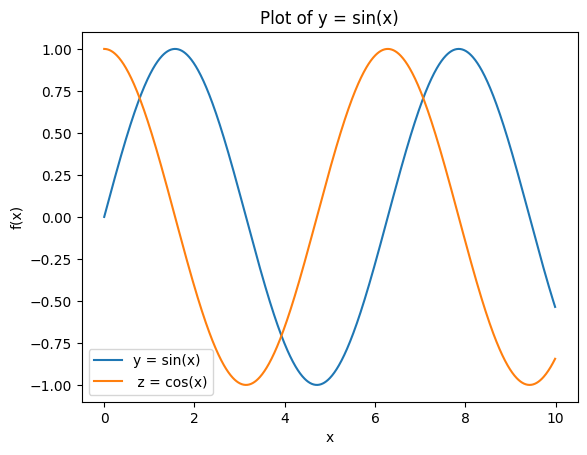

In [147]:
import matplotlib.pyplot as plt
plt.plot(m1, m2, label='y = sin(x)')
plt.plot(m1, m3, label=" z = cos(x)")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Plot of y = sin(x)')
plt.legend()
plt.grid(False)
plt.show()


In [180]:
#2.5.6
def f(x):
    return torch.log(x**2)*torch.sin(x)+1/x

In [181]:
x=torch.tensor([1.0,2.0],requires_grad=True)

In [182]:
f(x).backward(gradient=torch.ones(len(x)))
x.grad
x.grad_fn

In [184]:
print(x.grad)

tensor([0.6829, 0.0824])


In [ ]:
2*x*x**(-2)*torch.sin(x)